In [74]:
from luminis_mc import load_sweep_data
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
})

In [75]:
def max_theta_cbs(anisotropy) -> float:
    wavelength = 0.5145
    mean_free_path = 1
    in_radians = wavelength * (1 - anisotropy) / (2 * np.pi * mean_free_path)
    return np.degrees(in_radians)

In [76]:
base_dir = "/Users/niaggar/Documents/Thesis/Progress/02Mar26/"
dir_name = "2026-02-27_14-35-59_cbs_sweep_layered"
path_sweep = base_dir + dir_name
sweep_data = load_sweep_data(path_sweep)

dic_names = {
    "0000_n_layers_2": {
        "radius": 0.050,
        "anisotropy": 0.0659,
        "max_theta_cbs_deg": max_theta_cbs(0.0659),
        "max_theta_deg": 25.0,
    },
}

layer = sweep_data['0000_n_layers_2']
meta = layer.sensor_meta('farfieldcbs_timed')
print(meta)

N_t = meta['N_t']
pr_ff_S0_coh_t = []
pr_ff_S1_coh_t = []
pr_ff_S2_coh_t = []
pr_ff_S3_coh_t = []

pr_ff_S0_icoh_t = []
pr_ff_S1_icoh_t = []
pr_ff_S2_icoh_t = []
pr_ff_S3_icoh_t = []

for t in range(N_t):
    pr_ff_S0_coh_t.append(layer.derived(f'farfieldcbs_timed/coherent/t{t}_s0'))
    pr_ff_S1_coh_t.append(layer.derived(f'farfieldcbs_timed/coherent/t{t}_s1'))
    pr_ff_S2_coh_t.append(layer.derived(f'farfieldcbs_timed/coherent/t{t}_s2'))
    pr_ff_S3_coh_t.append(layer.derived(f'farfieldcbs_timed/coherent/t{t}_s3'))
    pr_ff_S0_icoh_t.append(layer.derived(f'farfieldcbs_timed/incoherent/t{t}_s0'))
    pr_ff_S1_icoh_t.append(layer.derived(f'farfieldcbs_timed/incoherent/t{t}_s1'))
    pr_ff_S2_icoh_t.append(layer.derived(f'farfieldcbs_timed/incoherent/t{t}_s2'))
    pr_ff_S3_icoh_t.append(layer.derived(f'farfieldcbs_timed/incoherent/t{t}_s3'))

pr_ff_S0_coh_t = np.array(pr_ff_S0_coh_t)
pr_ff_S1_coh_t = np.array(pr_ff_S1_coh_t)
pr_ff_S2_coh_t = np.array(pr_ff_S2_coh_t)
pr_ff_S3_coh_t = np.array(pr_ff_S3_coh_t)

pr_ff_S0_icoh_t = np.array(pr_ff_S0_icoh_t)
pr_ff_S1_icoh_t = np.array(pr_ff_S1_icoh_t)
pr_ff_S2_icoh_t = np.array(pr_ff_S2_icoh_t)
pr_ff_S3_icoh_t = np.array(pr_ff_S3_icoh_t)

pr_ff_S0_coh = layer.derived('farfieldcbs_total/coherent/s0')
pr_ff_S1_coh = layer.derived('farfieldcbs_total/coherent/s1')
pr_ff_S2_coh = layer.derived('farfieldcbs_total/coherent/s2')
pr_ff_S3_coh = layer.derived('farfieldcbs_total/coherent/s3')

pr_ff_S0_icoh = layer.derived('farfieldcbs_total/incoherent/s0')
pr_ff_S1_icoh = layer.derived('farfieldcbs_total/incoherent/s1')
pr_ff_S2_icoh = layer.derived('farfieldcbs_total/incoherent/s2')
pr_ff_S3_icoh = layer.derived('farfieldcbs_total/incoherent/s3')

Ico_coh_t = (pr_ff_S0_coh_t - pr_ff_S3_coh_t) / 2
Icross_coh_t = (pr_ff_S0_coh_t + pr_ff_S3_coh_t) / 2
Ico_incoh_t = (pr_ff_S0_icoh_t - pr_ff_S3_icoh_t) / 2
Icross_incoh_t = (pr_ff_S0_icoh_t + pr_ff_S3_icoh_t) / 2

Ico_coh_t_radial = np.mean(Ico_coh_t, axis=2)
Icross_coh_t_radial = np.mean(Icross_coh_t, axis=2)
Ico_incoh_t_radial = np.mean(Ico_incoh_t, axis=2)
Icross_incoh_t_radial = np.mean(Icross_incoh_t, axis=2)

etaco_t = Ico_coh_t_radial / Ico_incoh_t_radial
etacross_t = Icross_coh_t_radial / Icross_incoh_t_radial


Ico_coh = (pr_ff_S0_coh - pr_ff_S3_coh) / 2
Icross_coh = (pr_ff_S0_coh + pr_ff_S3_coh) / 2
Ico_incoh = (pr_ff_S0_icoh - pr_ff_S3_icoh) / 2
Icross_incoh = (pr_ff_S0_icoh + pr_ff_S3_icoh) / 2

Ico_coh_radial = np.mean(Ico_coh, axis=1)
Icross_coh_radial = np.mean(Icross_coh, axis=1)
Ico_incoh_radial = np.mean(Ico_incoh, axis=1)
Icross_incoh_radial = np.mean(Icross_incoh, axis=1)

etaco = Ico_coh_radial / Ico_incoh_radial
etacross = Icross_coh_radial / Icross_incoh_radial


print(Ico_coh_t_radial.shape)
print(Icross_coh_t_radial.shape)

theta_deg = np.degrees(np.linspace(0, meta['theta_max'], meta['N_theta']))




{'N_phi': np.int64(1), 'N_t': np.int64(20), 'N_theta': np.int64(500), 'absorb_photons': np.True_, 'backward_normal': array([-0., -0., -1.]), 'dphi': np.float64(6.283185307179586), 'dtheta': np.float64(0.0015707963267948967), 'estimator_enabled': np.False_, 'filter_direction': 'Both', 'filter_direction_enabled': np.False_, 'filter_phi_enabled': np.False_, 'filter_phi_max': np.float64(0.0), 'filter_phi_min': np.float64(0.0), 'filter_position_enabled': np.False_, 'filter_theta_enabled': np.True_, 'filter_theta_max': np.float64(0.7853981633974483), 'filter_theta_min': np.float64(0.0), 'filter_x_max': np.float64(0.0), 'filter_x_min': np.float64(0.0), 'filter_y_max': np.float64(0.0), 'filter_y_min': np.float64(0.0), 'hits': np.int64(845338903), 'id': '0', 'm_polarization': array([1., 0., 0.]), 'n_polarization': array([0., 1., 0.]), 'normal': array([0., 0., 1.]), 'origin': array([0., 0., 0.]), 'phi_max': np.float64(6.283185307179586), 'phi_stride': np.int64(2), 't_max': np.float64(40.0), 'the

In [77]:
def plot_data(theta_deg, Ico_coh_radial, Icross_coh_radial, Ico_incoh_radial, Icross_incoh_radial, etaco, etacross, title, max_x=20):
    fig = plt.figure(figsize=(16, 5))
    fig.suptitle(title, fontsize=16)

    theta_lim_a = max_theta_cbs(0.9199)
    theta_lim_b = max_theta_cbs(0.5944)

    ax = fig.add_subplot(1, 3, 1)
    plt.plot(theta_deg, Ico_coh_radial, label='$I_{coh}$')
    plt.plot(theta_deg, Ico_incoh_radial, label='$I_{incoh}$')
    plt.xlabel('Theta (degrees)')
    plt.ylabel('Intensity')
    plt.title('Co-polarized')
    plt.xlim(0, max_x)
    plt.legend()
    plt.axvline(theta_lim_a, color="g", linestyle=":")
    plt.axvline(theta_lim_b, color="r", linestyle=":")


    ax = fig.add_subplot(1, 3, 2)
    plt.plot(theta_deg, Icross_coh_radial, label='$I_{coh}$')
    plt.plot(theta_deg, Icross_incoh_radial, label='$I_{incoh}$')
    plt.xlabel('Theta (degrees)')
    plt.ylabel('Intensity')
    plt.title('Cross-polarized')
    plt.xlim(0, max_x)
    plt.legend()
    plt.axvline(theta_lim_a, color="g", linestyle=":")
    plt.axvline(theta_lim_b, color="r", linestyle=":")


    ax = fig.add_subplot(1, 3, 3)
    plt.plot(theta_deg, etaco, label='$\\eta_{co}$')
    plt.plot(theta_deg, etacross, label='$\\eta_{cross}$')
    plt.xlabel('Theta (degrees)')
    plt.title('Cross-polarized enhancement vs theta')
    plt.xlim(0, max_x)
    plt.legend()
    plt.axvline(theta_lim_a, color="g", linestyle=":")
    plt.axvline(theta_lim_b, color="r", linestyle=":")

    plt.tight_layout()
    plt.show()

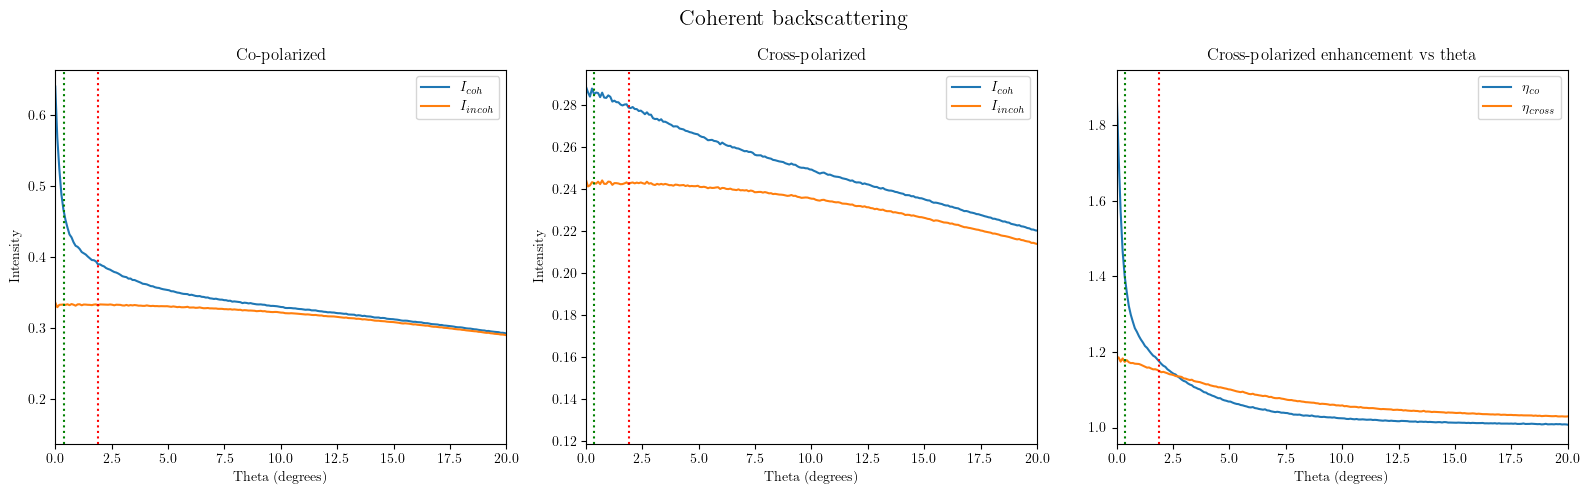

In [78]:
plot_data(theta_deg, Ico_coh_radial, Icross_coh_radial, Ico_incoh_radial, Icross_incoh_radial, etaco, etacross, title=f'Coherent backscattering', max_x=20)

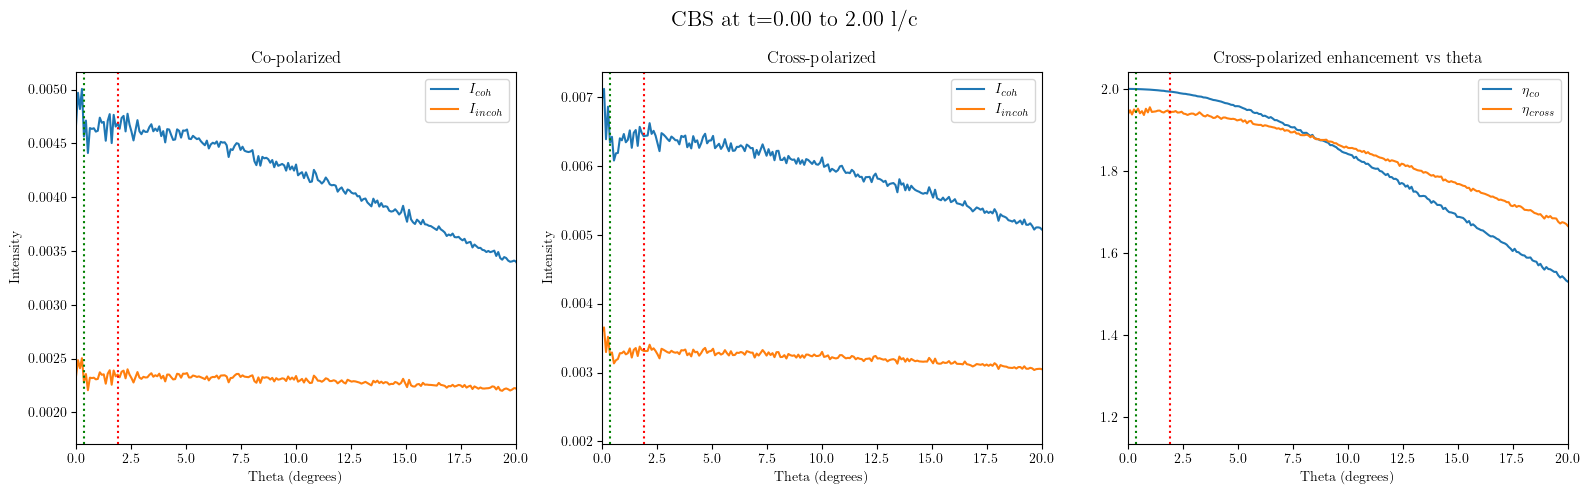

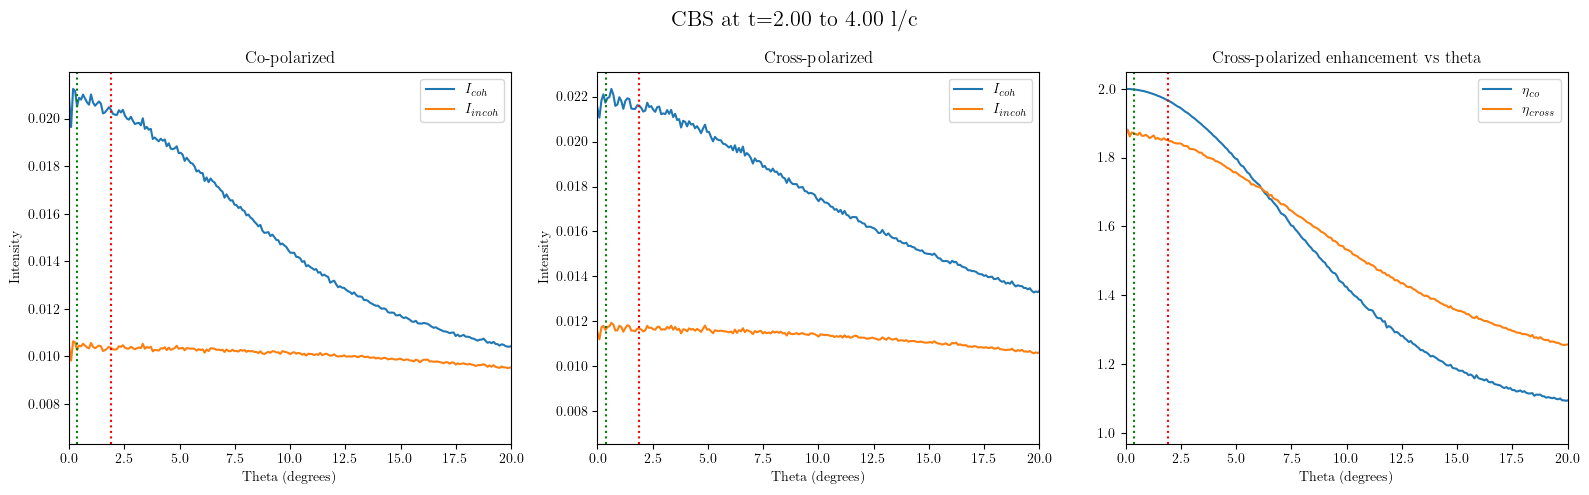

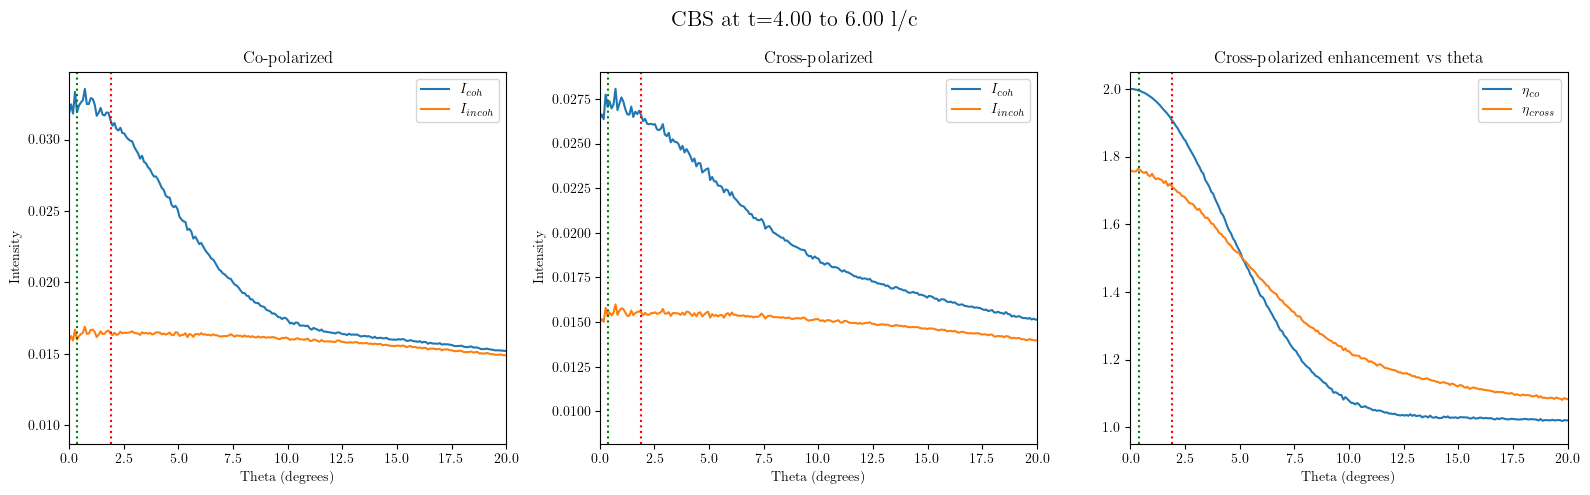

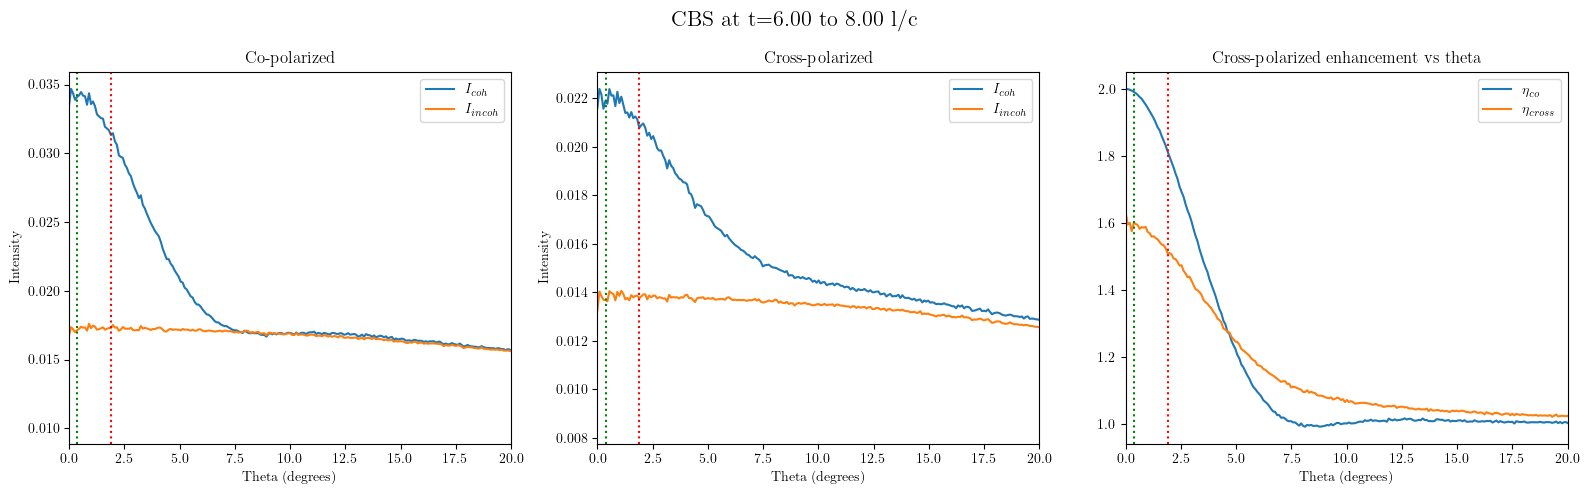

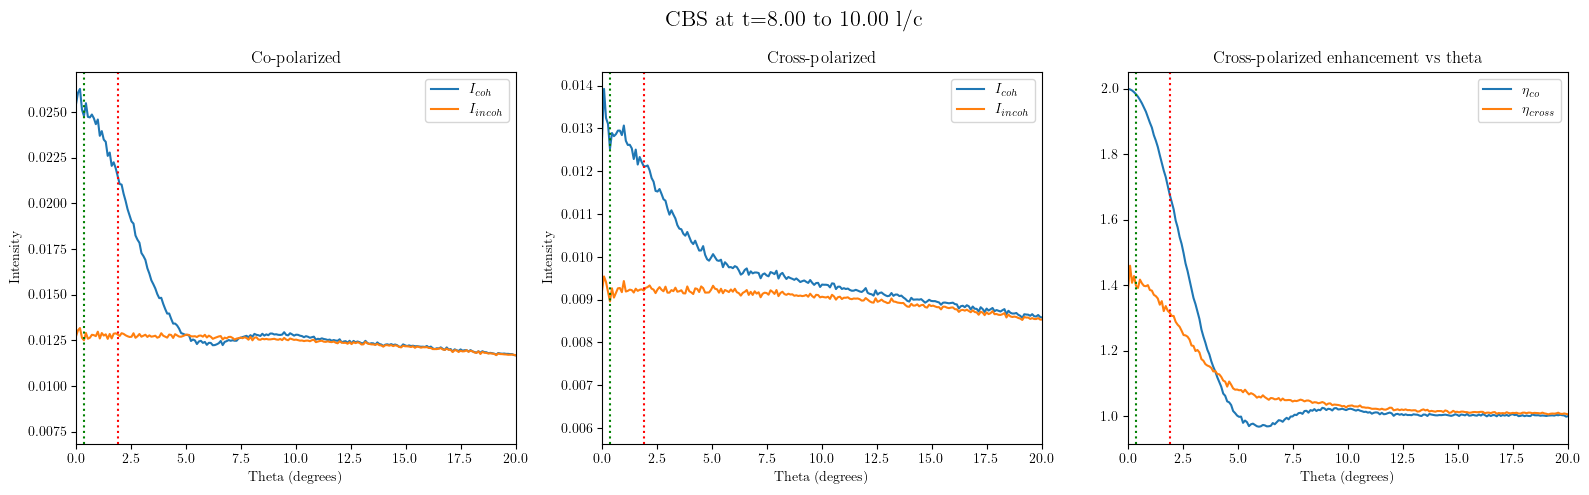

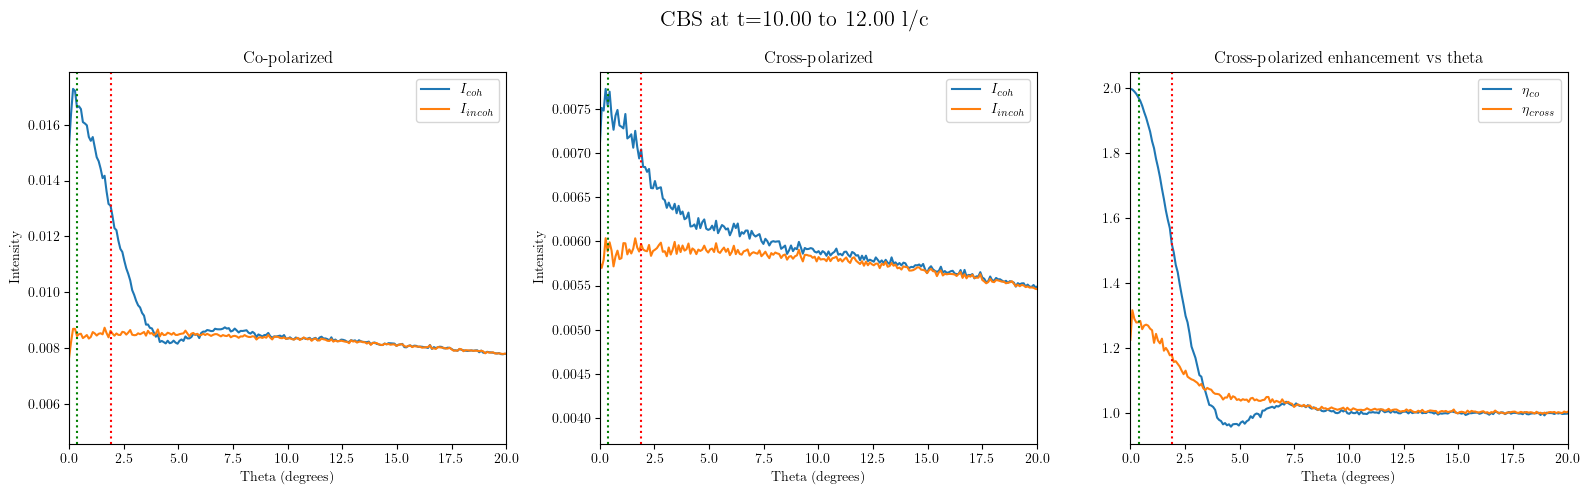

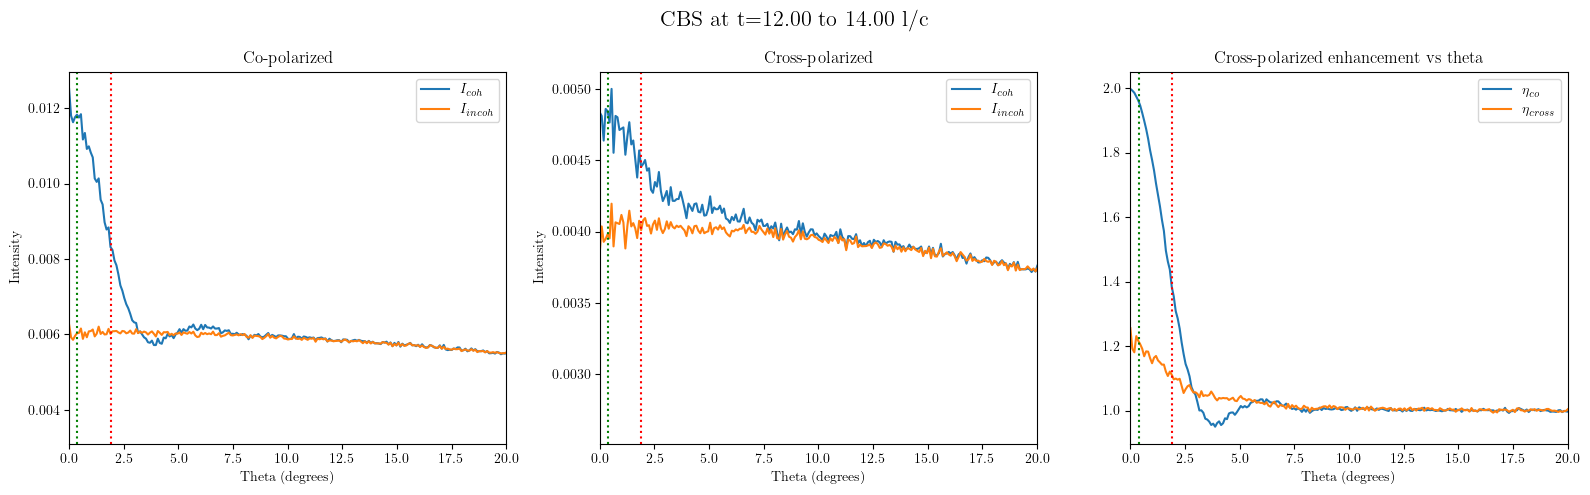

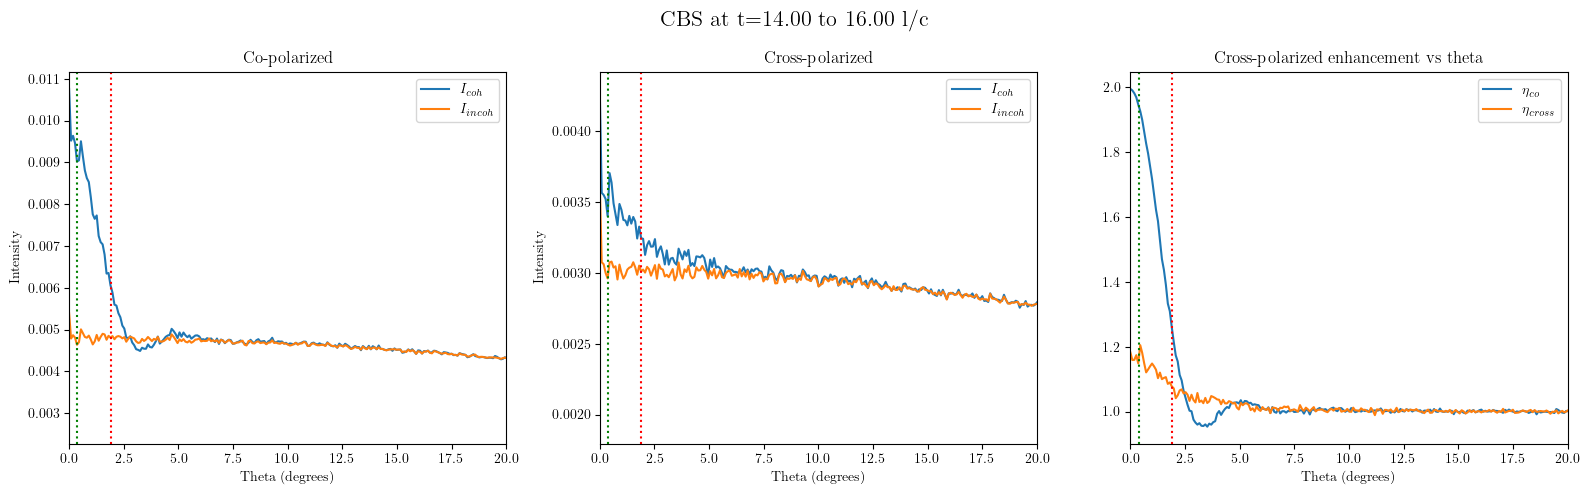

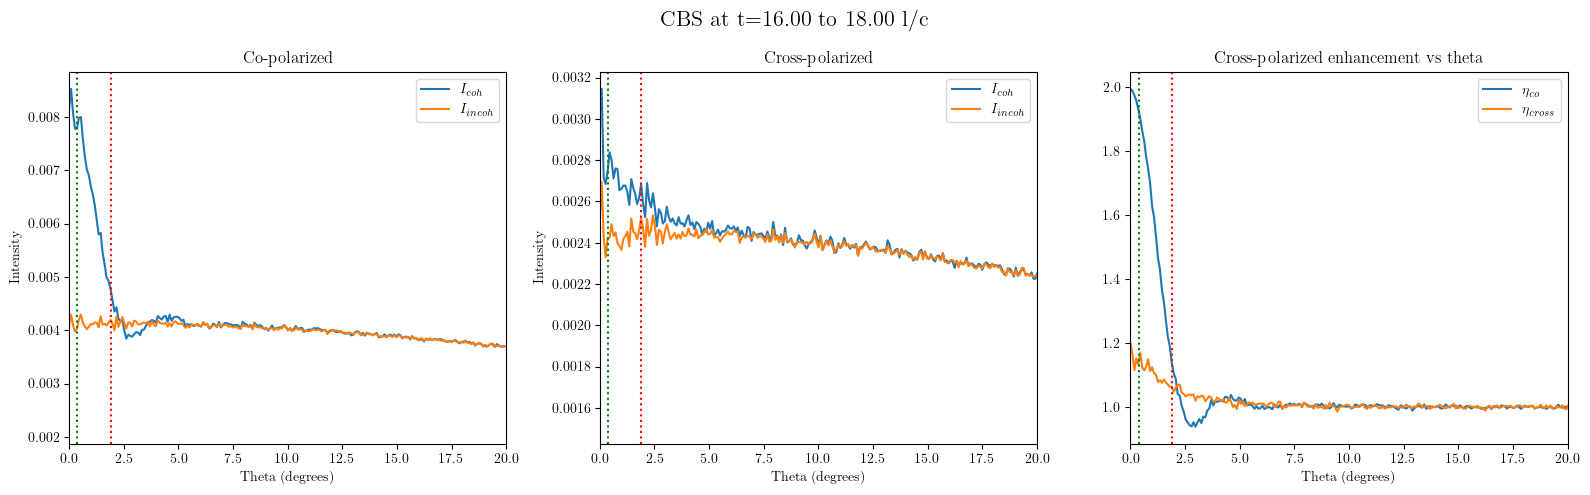

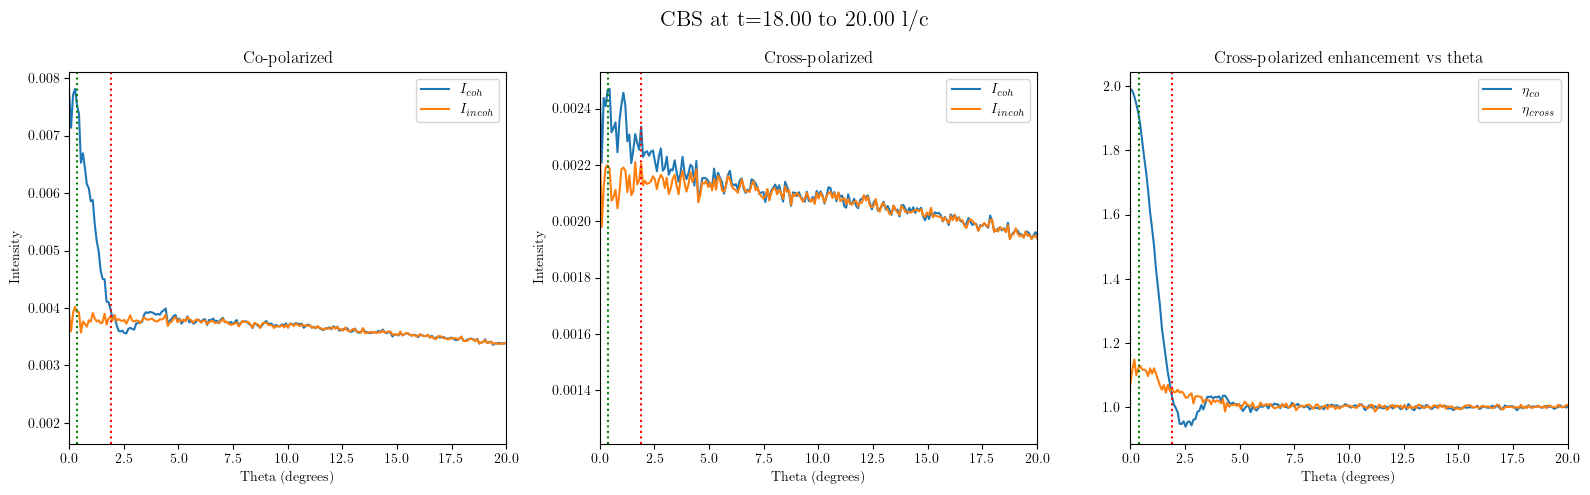

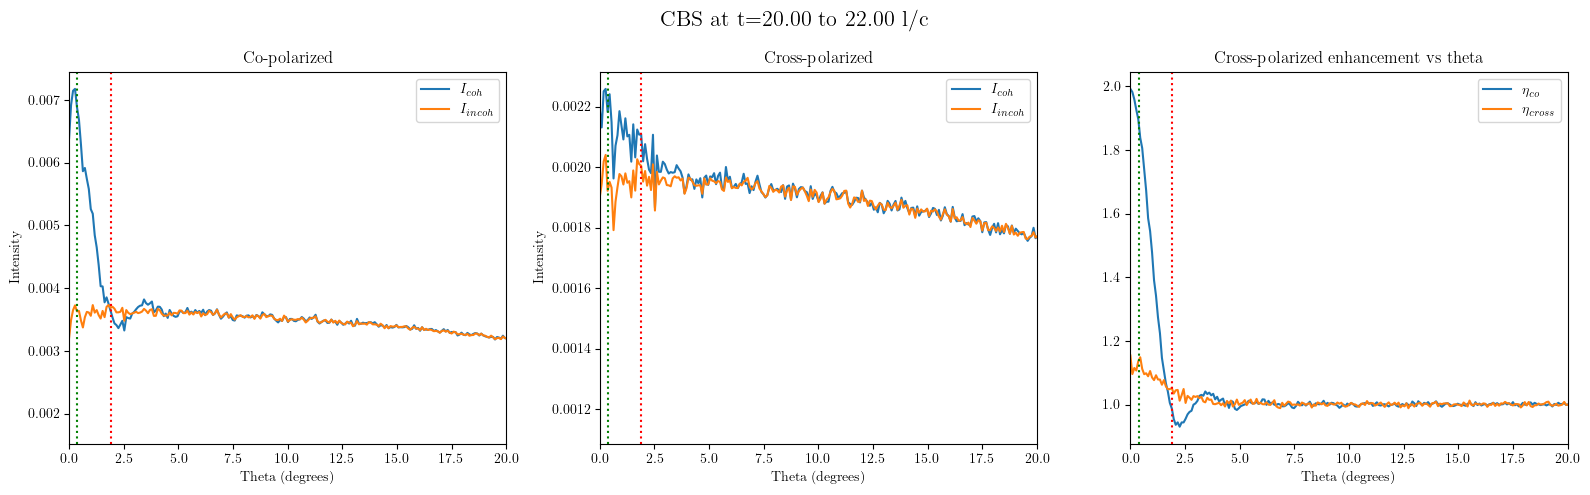

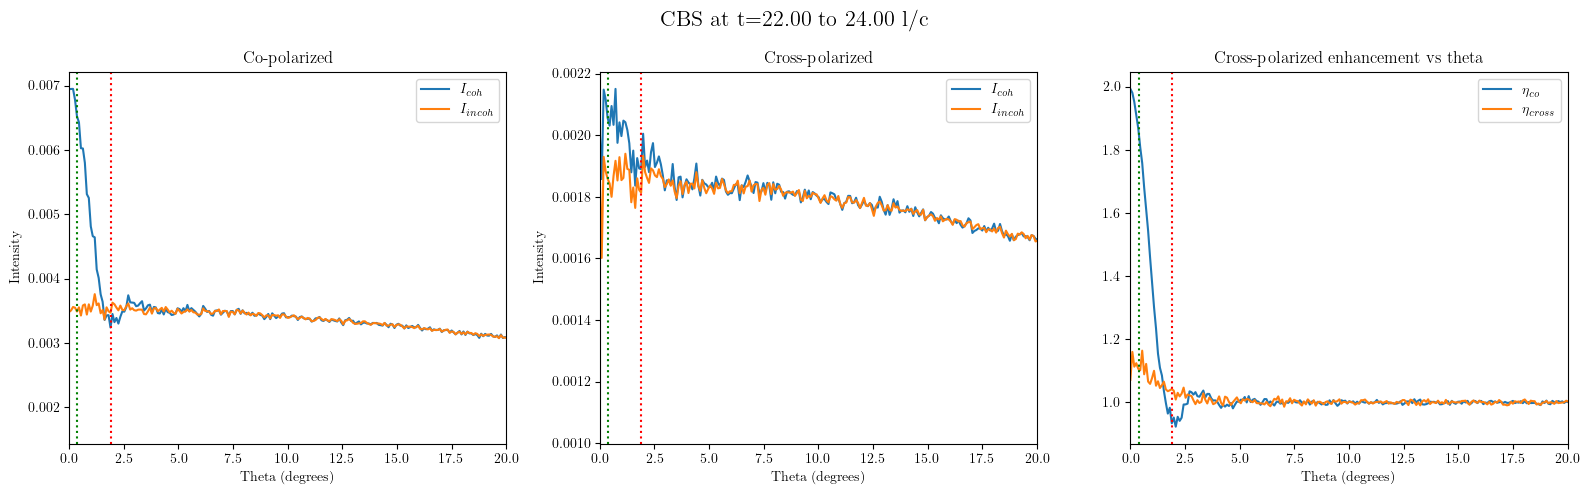

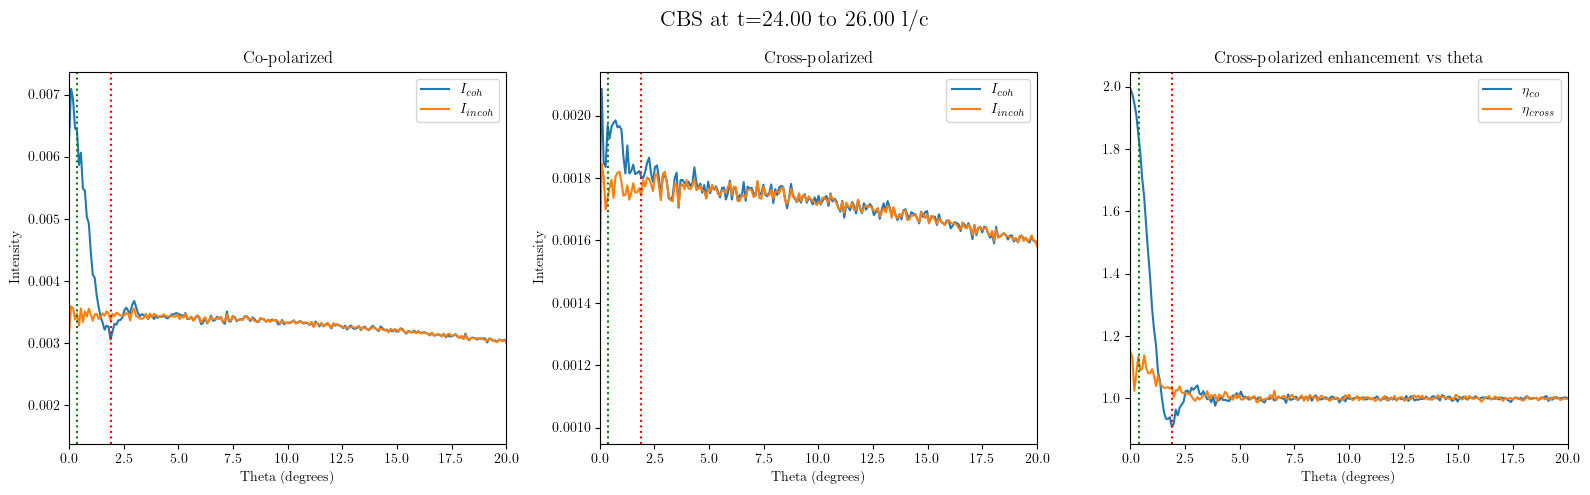

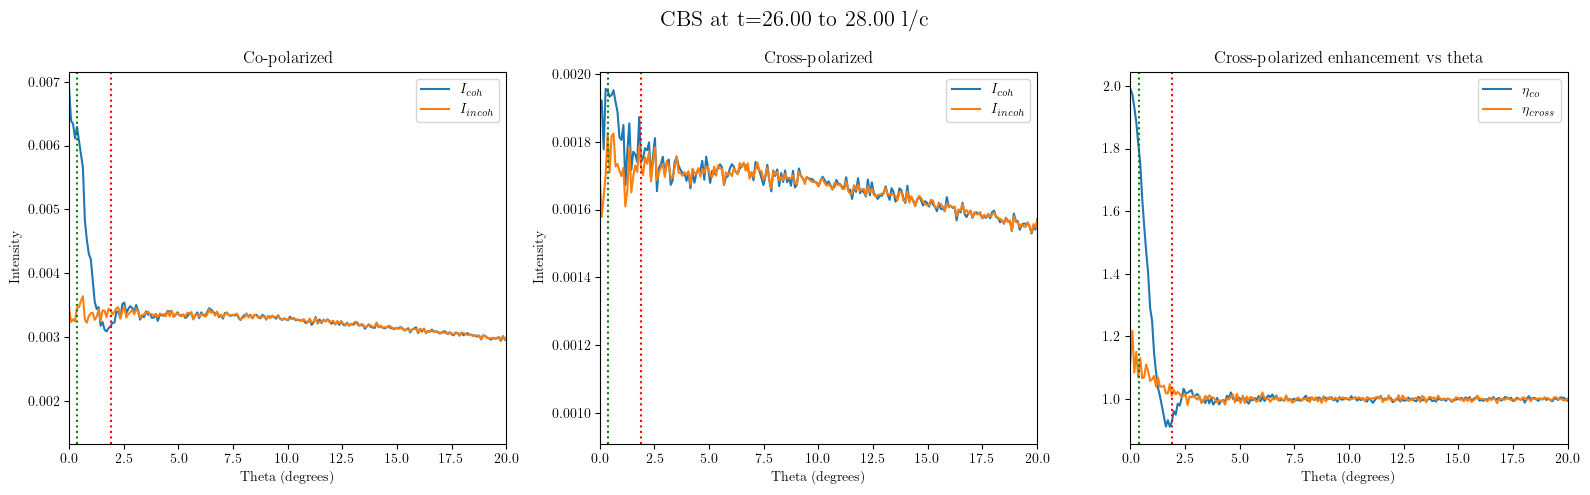

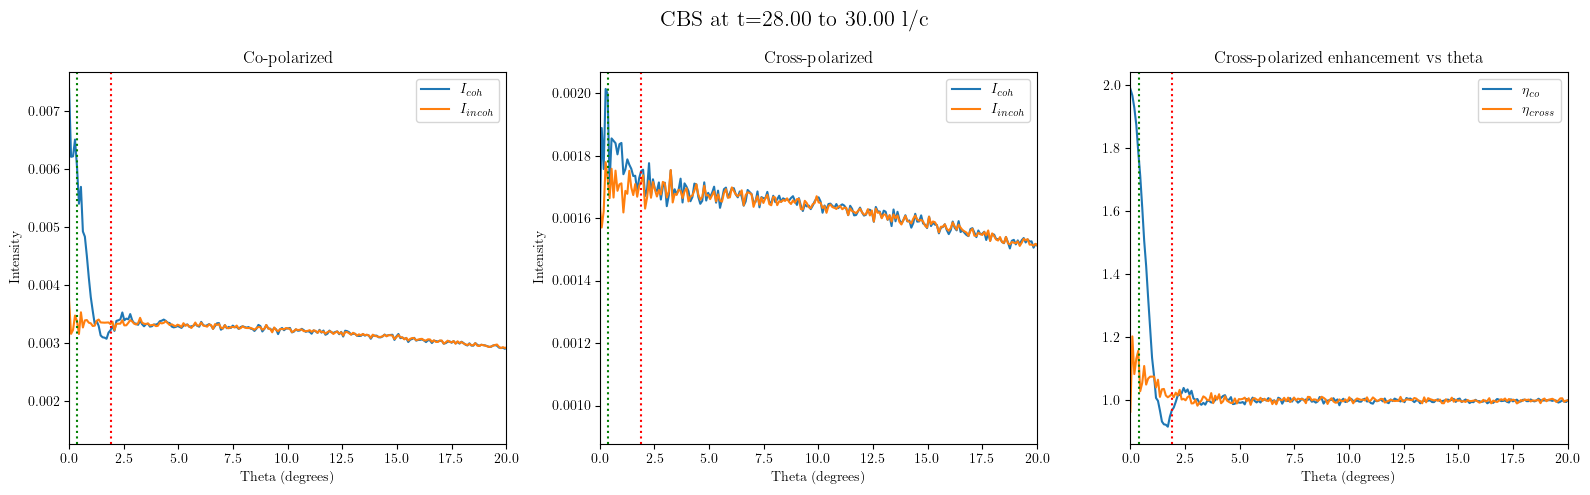

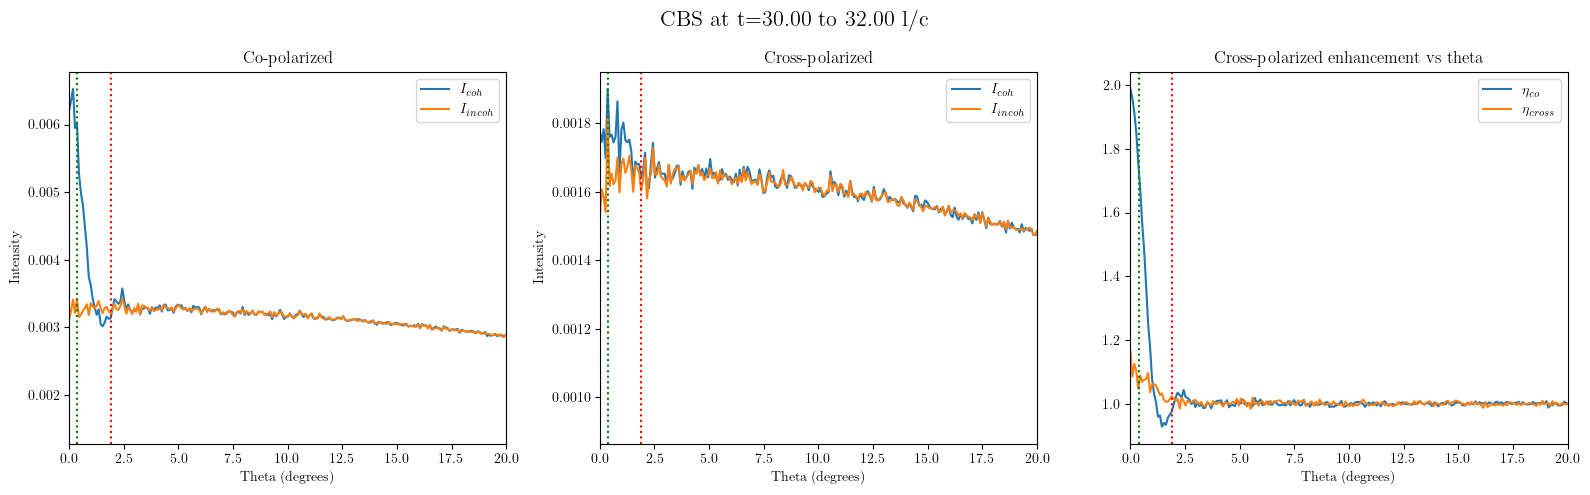

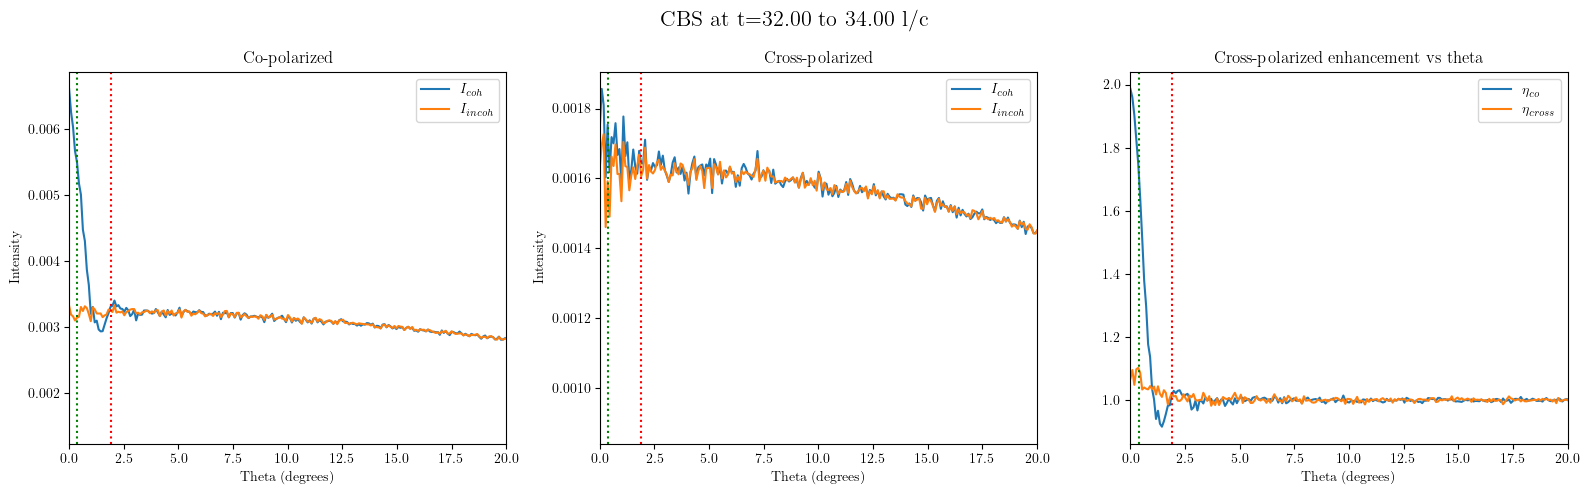

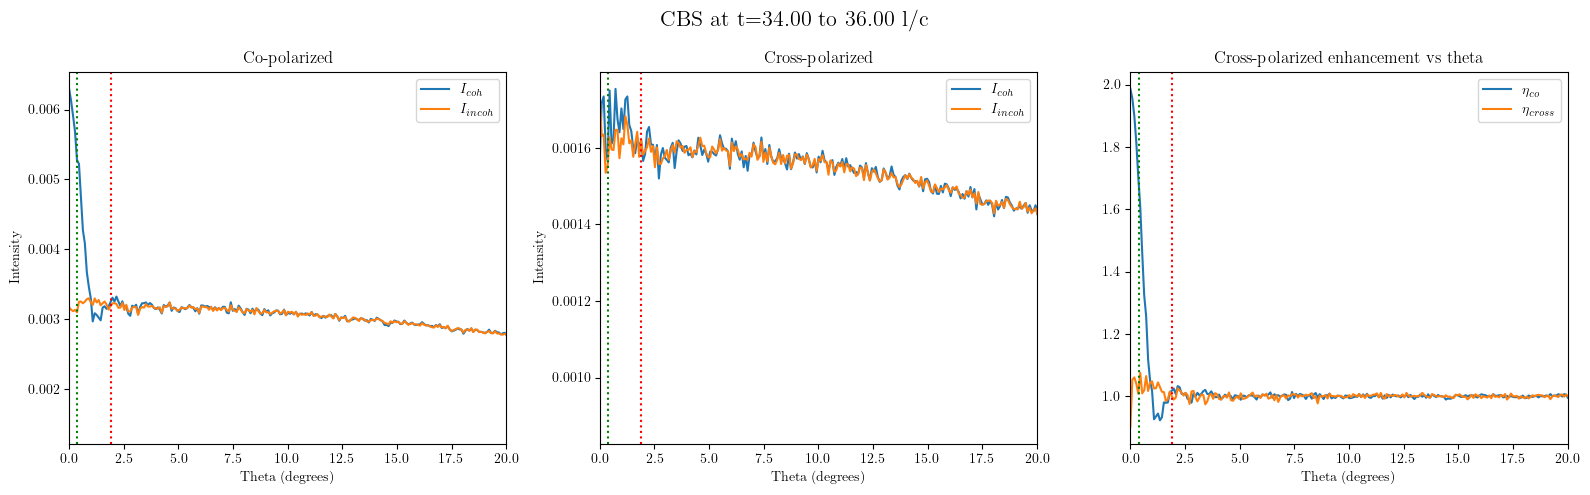

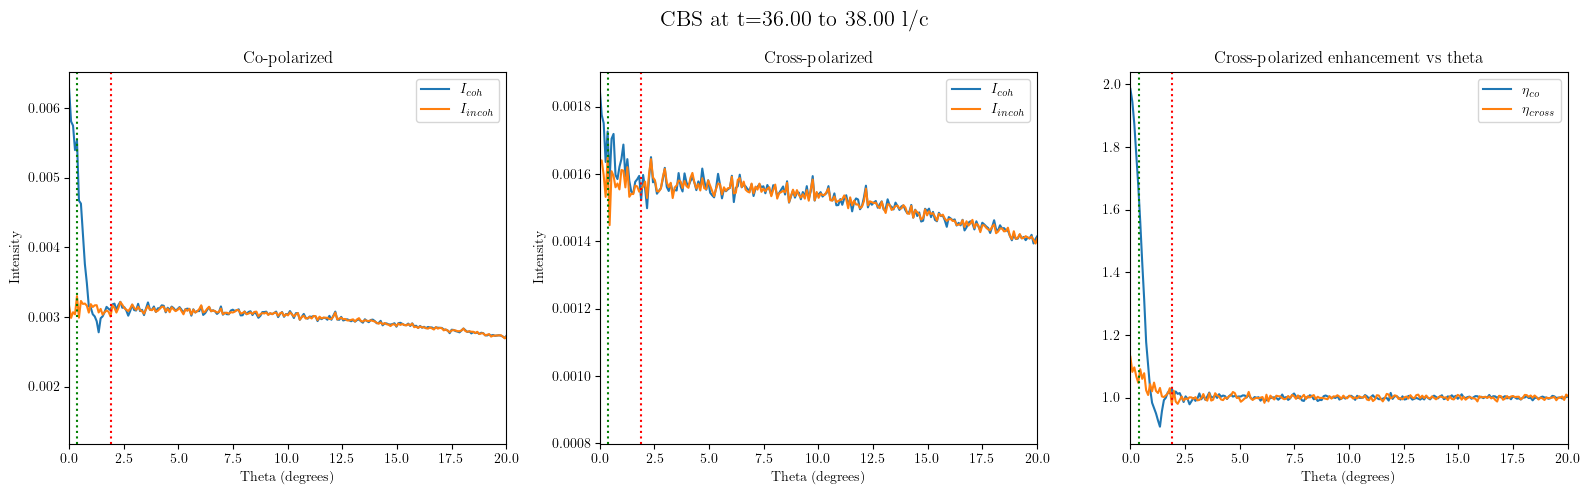

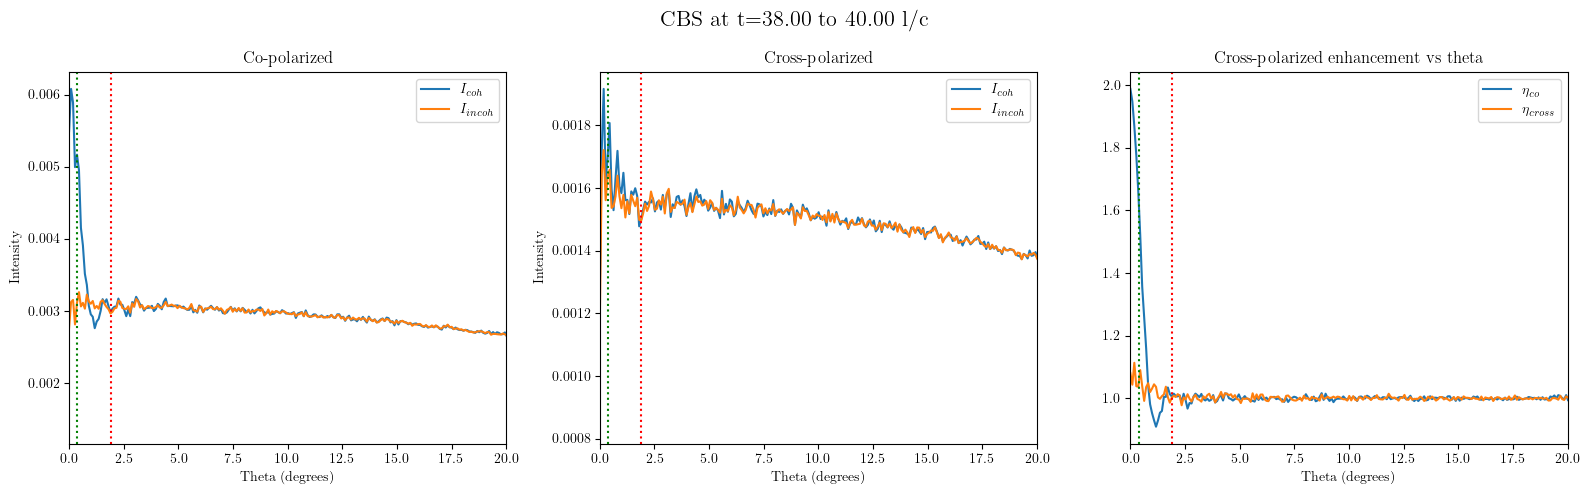

In [79]:
for i in range(meta['N_t']):
    t_min = (i) * 2
    t_max = (i + 1) * 2
    plot_data(theta_deg, Ico_coh_t_radial[i], Icross_coh_t_radial[i], Ico_incoh_t_radial[i], Icross_incoh_t_radial[i], etaco_t[i], etacross_t[i], title=f'CBS at t={t_min:.2f} to {t_max:.2f} l/c', max_x=20)